In [78]:
import matplotlib.pyplot as plt
import numpy as np

import os
import sys
import torch
import time
import seaborn as sns
sys.path.insert(0,os.path.abspath('/data/yww/notebook/pytorchtimseries'))
sys.path.insert(0,os.path.abspath('/data/yww/notebook/3110Diff'))

from torch_timeseries.dataloader.wrapper import MultiStepTimeFeatureSet, MultivariateFast
from torch.utils.data.dataloader import DataLoader

from src.experiments.DiffPTS import DiffPTSForecast
from src.experiments.NsDiff import NsDiffForecast, EPS
from src.experiments.TMDM import TMDMForecast
from src.experiments.D3U import D3UForecast
from src.experiments.RDIT import RDITForecast

In [84]:
def load_samples_trues(exp):
    self = exp
    full_dataset = MultiStepTimeFeatureSet(
        self.dataset,
        scaler=self.scaler,
        time_enc=self.timeenc,
        window=self.windows,
        horizon=self.horizon,
        steps=self.pred_len,
        include_raw=True,
        freq=self.dataset.freq,
        single_variate=False,
        scaler_fit=False,
        time_index=True,
    )

    all_batch_origin_x = []
    all_batch_origin_y = []

    all_batch_x = []
    all_batch_x_date_enc = []
    all_batch_y_date_enc = []
    all_batch_y = []

    all_x_index = []
    all_y_index = []


    for i in range(0, len(full_dataset), self.pred_len) :
        batch_x, batch_y, origin_x, origin_y, batch_x_date_enc, batch_y_date_enc, x_index, y_index = full_dataset[i]
        all_batch_origin_x.append(torch.tensor(origin_x))
        all_batch_origin_y.append(torch.tensor(origin_y))
        all_batch_x.append(torch.tensor(batch_x))
        all_batch_y.append(torch.tensor(batch_y))
        all_batch_x_date_enc.append(torch.tensor(batch_x_date_enc))
        all_batch_y_date_enc.append(torch.tensor(batch_y_date_enc))
        
        all_x_index.append(torch.tensor(x_index))
        all_y_index.append(torch.tensor(y_index))
    all_batch_origin_x = torch.stack(all_batch_origin_x, dim=0).to(self.device).float()[-12:]
    all_batch_origin_y = torch.stack(all_batch_origin_y, dim=0).to(self.device).float()[-12:]
    all_batch_x = torch.stack(all_batch_x, dim=0).to(self.device).float()[-12:]
    all_batch_y = torch.stack(all_batch_y, dim=0).to(self.device).float()[-12:]
    all_x_date_enc = torch.stack(all_batch_x_date_enc, dim=0).to(self.device).float()[-12:]
    all_y_date_enc = torch.stack(all_batch_y_date_enc, dim=0).to(self.device).float()[-12:]
    all_x_index = torch.stack(all_x_index, dim=0).to(self.device).float()[-12:]
    all_y_index = torch.stack(all_y_index, dim=0).to(self.device).float()[-12:]
    # outs = self._val_batch(all_batch_x, all_x_date_enc, all_y_date_enc, all_x_index, all_y_index) # B, T, N

    all_samples, all_trues = self._process_val_batch(
        all_batch_x, all_batch_y, all_x_date_enc, all_y_date_enc, plot=False
    )
    return all_samples, all_trues, all_batch_x, all_batch_y, all_x_date_enc, all_y_date_enc
    # fig, axes = plt.subplots(all_batch_x.shape[2])


# DiffPTS

### ETTm1

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import os
import sys
import torch
import time
import seaborn as sns
sys.path.insert(0,os.path.abspath('/data/yww/notebook/pytorchtimseries'))
sys.path.insert(0,os.path.abspath('/data/yww/notebook/3110Diff'))

from torch_timeseries.dataloader.wrapper import MultiStepTimeFeatureSet, MultivariateFast
from torch.utils.data.dataloader import DataLoader

from src.experiments.DiffPTS import DiffPTSForecast



In [15]:
exp = DiffPTSForecast(
    windows=168,
    pred_len=192,
    # epochs=10,
    # patience=5,
    save_dir='../results',
    data_path='../data',
    dataset_type="ETTm1",
    cond_backbone='patchtst'
)

In [38]:
# exp.run(2)
exp._setup_run(1)
exp._resume_run(1)

/data/yww/notebook/3110Diff/src/models/DiffPTS.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  assert (torch.tensor(self.betas_tilde) >= 0).all()


In [39]:
self = exp
full_dataset = MultiStepTimeFeatureSet(
    self.dataset,
    scaler=self.scaler,
    time_enc=self.timeenc,
    window=self.windows,
    horizon=self.horizon,
    steps=self.pred_len,
    include_raw=True,
    freq=self.dataset.freq,
    single_variate=False,
    scaler_fit=False,
    time_index=True,
)

all_batch_origin_x = []
all_batch_origin_y = []

all_batch_x = []
all_batch_x_date_enc = []
all_batch_y_date_enc = []
all_batch_y = []

all_x_index = []
all_y_index = []


for i in range(0, len(full_dataset), self.pred_len) :
    batch_x, batch_y, origin_x, origin_y, batch_x_date_enc, batch_y_date_enc, x_index, y_index = full_dataset[i]
    all_batch_origin_x.append(torch.tensor(origin_x))
    all_batch_origin_y.append(torch.tensor(origin_y))
    all_batch_x.append(torch.tensor(batch_x))
    all_batch_y.append(torch.tensor(batch_y))
    all_batch_x_date_enc.append(torch.tensor(batch_x_date_enc))
    all_batch_y_date_enc.append(torch.tensor(batch_y_date_enc))
    
    all_x_index.append(torch.tensor(x_index))
    all_y_index.append(torch.tensor(y_index))
all_batch_origin_x = torch.stack(all_batch_origin_x, dim=0).to(self.device).float()[-12:]
all_batch_origin_y = torch.stack(all_batch_origin_y, dim=0).to(self.device).float()[-12:]
all_batch_x = torch.stack(all_batch_x, dim=0).to(self.device).float()[-12:]
all_batch_y = torch.stack(all_batch_y, dim=0).to(self.device).float()[-12:]
all_x_date_enc = torch.stack(all_batch_x_date_enc, dim=0).to(self.device).float()[-12:]
all_y_date_enc = torch.stack(all_batch_y_date_enc, dim=0).to(self.device).float()[-12:]
all_x_index = torch.stack(all_x_index, dim=0).to(self.device).float()[-12:]
all_y_index = torch.stack(all_y_index, dim=0).to(self.device).float()[-12:]
# outs = self._val_batch(all_batch_x, all_x_date_enc, all_y_date_enc, all_x_index, all_y_index) # B, T, N

all_samples, all_trues = self._process_val_batch(
    all_batch_x, all_batch_y, all_x_date_enc, all_y_date_enc, plot=False
)

# fig, axes = plt.subplots(all_batch_x.shape[2])


In [ ]:

dec_inp_pred = torch.zeros(
    [all_batch_x.size(0), exp.pred_len, exp.dataset.num_features]
).to(exp.device)
dec_inp_label = all_batch_x[:, -exp.label_len :, :].to(exp.device)
dec_inp = torch.cat([dec_inp_label, dec_inp_pred], dim=1)
label_date = torch.concat([all_x_date_enc[:, -self.label_len:, :], all_y_date_enc], dim=1)


fx, _ = exp.cond_pred_model(all_batch_x, all_x_date_enc, dec_inp, label_date) #+ EPS # (B, O, N)
gx = exp.cond_pred_model_g(all_batch_x) #+ EPS # (B, O, N)


In [70]:
# length, sample
# remove largest 10 samples from plot_outs
# Remove largest k samples from plot_outs in the sample dimension (last axis)
def remove_largest_k(plot_outs, k=10):
    # plot_outs: (T, S) where S is the number of samples
    max_vals = plot_outs.max(axis=0)  # shape (S,)
    # Argsort descending by max, take the indices of the S-k smallest
    keep_indices = np.argsort(max_vals)[:-k]
    # Sorted, preserve original order
    keep_indices = np.sort(keep_indices)
    return plot_outs[:, keep_indices]

# For your case, after plot_outs assignment:
# plot_outs = remove_largest_k(plot_outs, k=10)


# plot_outs.shape


In [71]:
# plt.plot(gx.detach().cpu().numpy()[n, b:, :])

In [ ]:
# remove largest 10 samples
outs = all_samples
# outs = outs[outs.shape[0] - 10:]

n = 2
b = 3
outs = all_samples
plot_x = all_batch_x[:b, :, n].reshape(-1)
plot_y = all_batch_y[:b, :, n].reshape(-1)
plot_outs = outs[:b, :, n, :].detach().cpu().numpy().reshape(-1, 100)
# plot_outs = remove_largest_k(plot_outs, k=20)
percentiles = np.percentile(plot_outs, [5, 50, 96], axis=1)
percentiles.shape

(3, 576)

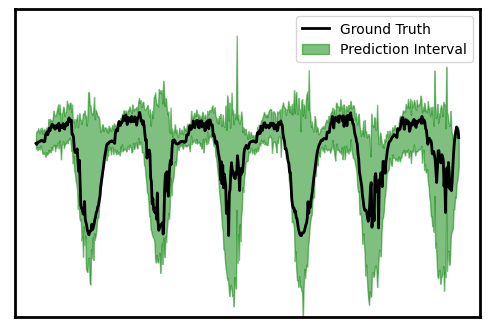

In [ ]:
# n = 2
# b = 7

plt.figure(figsize=(6, 4))
# out = outs[b, :, n, :].detach().cpu().numpy()
i_and_o =  torch.concat([plot_y], dim=0).detach().cpu().numpy() #  T


plt.plot(i_and_o, color='black', linewidth=2, label='Ground Truth')


# percentiles = np.percentile(out, [4, 50, 96], axis=1)

# plt.fill_between(o_index, percentiles[0], percentiles[2], color='green', alpha=0.45, label='Prediction Interval')
# I want to set a good looking color for the prediction interval
# Use a visually appealing gradient color for the prediction interval fill
from matplotlib.colors import LinearSegmentedColormap

# Create a custom colormap that fades from blue to pink to orange
cmap = LinearSegmentedColormap.from_list("pred_interval", ["#7289da", "#e573b3", "#ffa940"])
interval_color = cmap(0.6)  # Use a mid-range color from the colormap

plt.fill_between(
    range(percentiles[0].shape[0]),
    percentiles[0],
    percentiles[2],
    color='green',
    alpha=0.5,
    label='Prediction Interval'
)

plt.legend()

plt.gca().spines['top'].set_linewidth(2)  # Increase top border thickness
plt.gca().spines['right'].set_linewidth(2)  # Increase right border thickness
plt.gca().spines['left'].set_linewidth(2)   # Increase left border thickness
plt.gca().spines['bottom'].set_linewidth(2) # Increase bottom border thickness
# plt.grid()

plt.ylim([-8, 6])

# plt.show()# I want to remove x axis and y axis ticks
plt.xticks([])
plt.yticks([])
plt.savefig(f'DiffPTS_ETTm1_case.svg',bbox_inches='tight')

plt.show()

## ETTm2

In [ ]:
dataset = 'ETTm2'
exp = DiffPTSForecast(
    windows=168,
    pred_len=192,
    # epochs=10,
    # patience=5,
    save_dir='../results',
    data_path='../data',
    dataset_type="ETTm2",
    cond_backbone='patchtst'
)

## ETTh1

## ETTh2

## ECL

## ILI

## Solar

## EXG

## Traffic

# NsDiff

## ETTm1

In [35]:
import matplotlib.pyplot as plt
import numpy as np

import os
import sys
import torch
import time
import seaborn as sns
from sklearn.metrics.pairwise import linear_kernel
from scipy.linalg import svd

from sklearn.metrics.pairwise import linear_kernel
sys.path.insert(0,os.path.abspath('/data/yww/notebook/pytorchtimseries'))
sys.path.insert(0,os.path.abspath('/data/yww/notebook/3110Diff'))
from tqdm.notebook import tqdm
from src.layer.nsdiff_utils import q_sample, p_sample_loop, cal_sigma12, cal_sigma_tilde, cal_forward_noise
from torch_timeseries.dataloader.wrapper import MultiStepTimeFeatureSet, MultivariateFast

from src.utils.sigma import wv_sigma, wv_sigma_trailing


from src.experiments.NsDiff import NsDiffForecast, EPS


In [36]:
exp = NsDiffForecast(
    model_type="NsDiff4",
    windows=168,
    pred_len=192,
    epochs=10,
    patience=5,
    save_dir='../results',
    data_path='../data',
    dataset_type="ETTm1",
    lr=0.001,
    rolling_length=96,
    diffusion_steps=10,
)
# exp.run(1)
exp._setup_run(1)
exp._resume_run(1)

Using downloaded and verified file: ../data/ETTm1/ETTm1.csv
train steps: 34201
val steps: 32
test steps: 32


/data/yww/notebook/3110Diff/src/models/NsDiff.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  assert (torch.tensor(self.betas_tilde) >= 0).all()


In [7]:
self = exp
full_dataset = MultiStepTimeFeatureSet(
    self.dataset,
    scaler=self.scaler,
    time_enc=self.timeenc,
    window=self.windows,
    horizon=self.horizon,
    steps=self.pred_len,
    include_raw=True,
    freq=self.dataset.freq,
    single_variate=False,
    scaler_fit=False,
    time_index=True,
)

all_batch_origin_x = []
all_batch_origin_y = []

all_batch_x = []
all_batch_x_date_enc = []
all_batch_y_date_enc = []
all_batch_y = []

all_x_index = []
all_y_index = []


for i in range(0, len(full_dataset), self.pred_len) :
    batch_x, batch_y, origin_x, origin_y, batch_x_date_enc, batch_y_date_enc, x_index, y_index = full_dataset[i]
    all_batch_origin_x.append(torch.tensor(origin_x))
    all_batch_origin_y.append(torch.tensor(origin_y))
    all_batch_x.append(torch.tensor(batch_x))
    all_batch_y.append(torch.tensor(batch_y))
    all_batch_x_date_enc.append(torch.tensor(batch_x_date_enc))
    all_batch_y_date_enc.append(torch.tensor(batch_y_date_enc))
    
    all_x_index.append(torch.tensor(x_index))
    all_y_index.append(torch.tensor(y_index))
all_batch_origin_x = torch.stack(all_batch_origin_x, dim=0).to(self.device).float()[-12:]
all_batch_origin_y = torch.stack(all_batch_origin_y, dim=0).to(self.device).float()[-12:]
all_batch_x = torch.stack(all_batch_x, dim=0).to(self.device).float()[-12:]
all_batch_y = torch.stack(all_batch_y, dim=0).to(self.device).float()[-12:]
all_x_date_enc = torch.stack(all_batch_x_date_enc, dim=0).to(self.device).float()[-12:]
all_y_date_enc = torch.stack(all_batch_y_date_enc, dim=0).to(self.device).float()[-12:]
all_x_index = torch.stack(all_x_index, dim=0).to(self.device).float()[-12:]
all_y_index = torch.stack(all_y_index, dim=0).to(self.device).float()[-12:]
# outs = self._val_batch(all_batch_x, all_x_date_enc, all_y_date_enc, all_x_index, all_y_index) # B, T, N

all_samples, all_trues = self._process_val_batch(
    all_batch_x, all_batch_y, all_x_date_enc, all_y_date_enc
)

# fig, axes = plt.subplots(all_batch_x.shape[2])


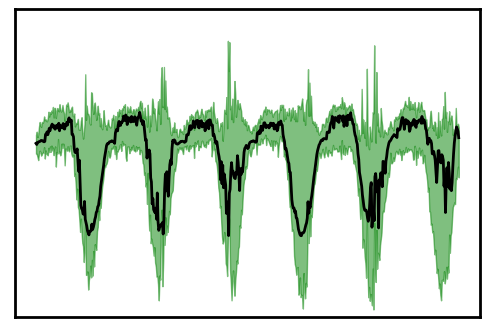

In [8]:
# n = 2
# b = 7
outs = all_samples

n = 2
b = 3
outs = all_samples
plot_x = all_batch_x[:b, :, n].reshape(-1)
plot_y = all_batch_y[:b, :, n].reshape(-1)
plot_outs = outs[:b, :, n, :].detach().cpu().numpy().reshape(-1, 100)
percentiles = np.percentile(plot_outs, [4, 50, 96], axis=1)
percentiles.shape
plt.figure(figsize=(6, 4))
# out = outs[b, :, n, :].detach().cpu().numpy()
i_and_o =  torch.concat([plot_y], dim=0).detach().cpu().numpy() #  T


plt.plot(i_and_o, color='black', linewidth=2, label='Ground Truth')


# percentiles = np.percentile(out, [4, 50, 96], axis=1)

# plt.fill_between(o_index, percentiles[0], percentiles[2], color='green', alpha=0.45, label='Prediction Interval')
# I want to set a good looking color for the prediction interval
# Use a visually appealing gradient color for the prediction interval fill
from matplotlib.colors import LinearSegmentedColormap

# Create a custom colormap that fades from blue to pink to orange
cmap = LinearSegmentedColormap.from_list("pred_interval", ["#7289da", "#e573b3", "#ffa940"])
interval_color = cmap(0.6)  # Use a mid-range color from the colormap

plt.fill_between(
    range(percentiles[0].shape[0]),
    percentiles[0],
    percentiles[2],
    color='green',
    alpha=0.5,
    label='Prediction Interval'
)

# plt.legend()

plt.gca().spines['top'].set_linewidth(2)  # Increase top border thickness
plt.gca().spines['right'].set_linewidth(2)  # Increase right border thickness
plt.gca().spines['left'].set_linewidth(2)   # Increase left border thickness
plt.gca().spines['bottom'].set_linewidth(2) # Increase bottom border thickness
# plt.grid()

plt.ylim([-8, 6])

# plt.show()# I want to remove x axis and y axis ticks
plt.xticks([])
plt.yticks([])
plt.savefig(f'NsDiff_ETTm1_case.svg',bbox_inches='tight')

plt.show()

## ETTm2

# RDIT

## ETTm1

In [40]:
import matplotlib.pyplot as plt
import numpy as np

import os
import sys
import torch
import time
import seaborn as sns
sys.path.insert(0,os.path.abspath('/data/yww/notebook/pytorchtimseries'))
sys.path.insert(0,os.path.abspath('/data/yww/notebook/3110Diff'))

from torch_timeseries.dataloader.wrapper import MultiStepTimeFeatureSet, MultivariateFast
from torch.utils.data.dataloader import DataLoader

from src.experiments.RDIT import RDITForecast

exp = RDITForecast(
    windows=168,
    pred_len=192,
    # epochs=10,
    # patience=5,
    save_dir='../results',
    data_path='../data',
    dataset_type="ETTm1",
    sigma_mode='res',
    # lr=0.001,
    # rolling_length=96,
    # diffusion_steps=10,
)
# exp.run(1)
exp._setup_run(1)
exp._resume_run(1)

Using downloaded and verified file: ../data/ETTm1/ETTm1.csv
train steps: 34201
val steps: 32
test steps: 32


/data/yww/notebook/3110Diff/src/models/DiffPTS.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  assert (torch.tensor(self.betas_tilde) >= 0).all()


In [41]:
self = exp
full_dataset = MultiStepTimeFeatureSet(
    self.dataset,
    scaler=self.scaler,
    time_enc=self.timeenc,
    window=self.windows,
    horizon=self.horizon,
    steps=self.pred_len,
    include_raw=True,
    freq=self.dataset.freq,
    single_variate=False,
    scaler_fit=False,
    time_index=True,
)

all_batch_origin_x = []
all_batch_origin_y = []

all_batch_x = []
all_batch_x_date_enc = []
all_batch_y_date_enc = []
all_batch_y = []

all_x_index = []
all_y_index = []


for i in range(0, len(full_dataset), self.pred_len) :
    batch_x, batch_y, origin_x, origin_y, batch_x_date_enc, batch_y_date_enc, x_index, y_index = full_dataset[i]
    all_batch_origin_x.append(torch.tensor(origin_x))
    all_batch_origin_y.append(torch.tensor(origin_y))
    all_batch_x.append(torch.tensor(batch_x))
    all_batch_y.append(torch.tensor(batch_y))
    all_batch_x_date_enc.append(torch.tensor(batch_x_date_enc))
    all_batch_y_date_enc.append(torch.tensor(batch_y_date_enc))
    
    all_x_index.append(torch.tensor(x_index))
    all_y_index.append(torch.tensor(y_index))
all_batch_origin_x = torch.stack(all_batch_origin_x, dim=0).to(self.device).float()[-12:]
all_batch_origin_y = torch.stack(all_batch_origin_y, dim=0).to(self.device).float()[-12:]
all_batch_x = torch.stack(all_batch_x, dim=0).to(self.device).float()[-12:]
all_batch_y = torch.stack(all_batch_y, dim=0).to(self.device).float()[-12:]
all_x_date_enc = torch.stack(all_batch_x_date_enc, dim=0).to(self.device).float()[-12:]
all_y_date_enc = torch.stack(all_batch_y_date_enc, dim=0).to(self.device).float()[-12:]
all_x_index = torch.stack(all_x_index, dim=0).to(self.device).float()[-12:]
all_y_index = torch.stack(all_y_index, dim=0).to(self.device).float()[-12:]
# outs = self._val_batch(all_batch_x, all_x_date_enc, all_y_date_enc, all_x_index, all_y_index) # B, T, N

all_samples, all_trues = self._process_val_batch(
    all_batch_x, all_batch_y, all_x_date_enc, all_y_date_enc
)

# fig, axes = plt.subplots(all_batch_x.shape[2])


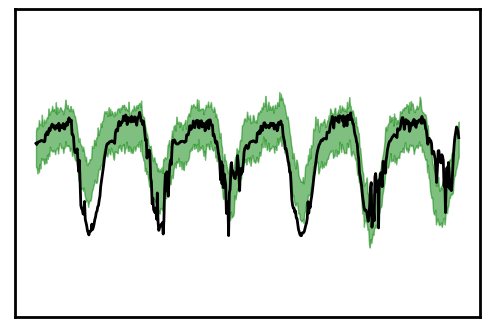

In [42]:
# n = 2
# b = 7
outs = all_samples

n = 2
b = 3
outs = all_samples
plot_x = all_batch_x[:b, :, n].reshape(-1)
plot_y = all_batch_y[:b, :, n].reshape(-1)
plot_outs = outs[:b, :, n, :].detach().cpu().numpy().reshape(-1, 100)
percentiles = np.percentile(plot_outs, [4, 50, 96], axis=1)
percentiles.shape
plt.figure(figsize=(6, 4))
# out = outs[b, :, n, :].detach().cpu().numpy()
i_and_o =  torch.concat([plot_y], dim=0).detach().cpu().numpy() #  T


plt.plot(i_and_o, color='black', linewidth=2, label='Ground Truth')


# percentiles = np.percentile(out, [4, 50, 96], axis=1)

# plt.fill_between(o_index, percentiles[0], percentiles[2], color='green', alpha=0.45, label='Prediction Interval')
# I want to set a good looking color for the prediction interval
# Use a visually appealing gradient color for the prediction interval fill
from matplotlib.colors import LinearSegmentedColormap

# Create a custom colormap that fades from blue to pink to orange
cmap = LinearSegmentedColormap.from_list("pred_interval", ["#7289da", "#e573b3", "#ffa940"])
interval_color = cmap(0.6)  # Use a mid-range color from the colormap

plt.fill_between(
    range(percentiles[0].shape[0]),
    percentiles[0],
    percentiles[2],
    color='green',
    alpha=0.5,
    label='Prediction Interval'
)

# plt.legend()

plt.gca().spines['top'].set_linewidth(2)  # Increase top border thickness
plt.gca().spines['right'].set_linewidth(2)  # Increase right border thickness
plt.gca().spines['left'].set_linewidth(2)   # Increase left border thickness
plt.gca().spines['bottom'].set_linewidth(2) # Increase bottom border thickness
# plt.grid()

plt.ylim([-8, 6])

# plt.show()# I want to remove x axis and y axis ticks
plt.xticks([])
plt.yticks([])
plt.savefig(f'RDIT_ETTm1_case.svg',bbox_inches='tight')

plt.show()

# D3U

## ETTm1

In [230]:
import matplotlib.pyplot as plt
import numpy as np

import os
import sys
import torch
import time
import seaborn as sns
sys.path.insert(0,os.path.abspath('/data/yww/notebook/pytorchtimseries'))
sys.path.insert(0,os.path.abspath('/data/yww/notebook/3110Diff'))

from torch_timeseries.dataloader.wrapper import MultiStepTimeFeatureSet, MultivariateFast
from torch.utils.data.dataloader import DataLoader

from src.experiments.D3U import D3UForecast

exp = D3UForecast(
    windows=168,
    pred_len=192,
    save_dir='../results',
    data_path='../data',
    dataset_type="ETTm1",
)
# exp.run(1)
exp._setup_run(1)
exp._resume_run(1)

Using downloaded and verified file: ../data/ETTm1/ETTm1.csv
train steps: 34201
val steps: 32
test steps: 32


/data/yww/notebook/3110Diff/src/models/D3U.py:44: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  assert (torch.tensor(self.betas_tilde) >= 0).all()


In [44]:
self = exp
full_dataset = MultiStepTimeFeatureSet(
    self.dataset,
    scaler=self.scaler,
    time_enc=self.timeenc,
    window=self.windows,
    horizon=self.horizon,
    steps=self.pred_len,
    include_raw=True,
    freq=self.dataset.freq,
    single_variate=False,
    scaler_fit=False,
    time_index=True,
)

all_batch_origin_x = []
all_batch_origin_y = []

all_batch_x = []
all_batch_x_date_enc = []
all_batch_y_date_enc = []
all_batch_y = []

all_x_index = []
all_y_index = []


for i in range(0, len(full_dataset), self.pred_len) :
    batch_x, batch_y, origin_x, origin_y, batch_x_date_enc, batch_y_date_enc, x_index, y_index = full_dataset[i]
    all_batch_origin_x.append(torch.tensor(origin_x))
    all_batch_origin_y.append(torch.tensor(origin_y))
    all_batch_x.append(torch.tensor(batch_x))
    all_batch_y.append(torch.tensor(batch_y))
    all_batch_x_date_enc.append(torch.tensor(batch_x_date_enc))
    all_batch_y_date_enc.append(torch.tensor(batch_y_date_enc))
    
    all_x_index.append(torch.tensor(x_index))
    all_y_index.append(torch.tensor(y_index))
all_batch_origin_x = torch.stack(all_batch_origin_x, dim=0).to(self.device).float()[-12:]
all_batch_origin_y = torch.stack(all_batch_origin_y, dim=0).to(self.device).float()[-12:]
all_batch_x = torch.stack(all_batch_x, dim=0).to(self.device).float()[-12:]
all_batch_y = torch.stack(all_batch_y, dim=0).to(self.device).float()[-12:]
all_x_date_enc = torch.stack(all_batch_x_date_enc, dim=0).to(self.device).float()[-12:]
all_y_date_enc = torch.stack(all_batch_y_date_enc, dim=0).to(self.device).float()[-12:]
all_x_index = torch.stack(all_x_index, dim=0).to(self.device).float()[-12:]
all_y_index = torch.stack(all_y_index, dim=0).to(self.device).float()[-12:]
# outs = self._val_batch(all_batch_x, all_x_date_enc, all_y_date_enc, all_x_index, all_y_index) # B, T, N

all_samples, all_trues = self._process_val_batch(
    all_batch_x, all_batch_y, all_x_date_enc, all_y_date_enc
)

# fig, axes = plt.subplots(all_batch_x.shape[2])


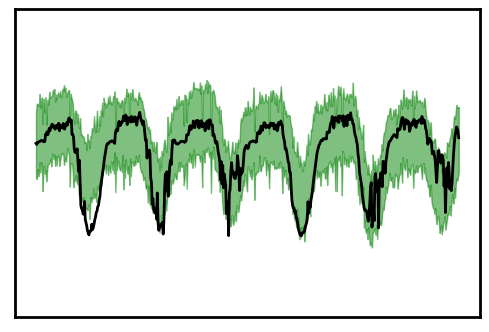

In [45]:
# n = 2
# b = 7
outs = all_samples

n = 2
b = 3
outs = all_samples
plot_x = all_batch_x[:b, :, n].reshape(-1)
plot_y = all_batch_y[:b, :, n].reshape(-1)
plot_outs = outs[:b, :, n, :].detach().cpu().numpy().reshape(-1, 100)
percentiles = np.percentile(plot_outs, [4, 50, 96], axis=1)
percentiles.shape
plt.figure(figsize=(6, 4))
# out = outs[b, :, n, :].detach().cpu().numpy()
i_and_o =  torch.concat([plot_y], dim=0).detach().cpu().numpy() #  T


plt.plot(i_and_o, color='black', linewidth=2, label='Ground Truth')


# percentiles = np.percentile(out, [4, 50, 96], axis=1)

# plt.fill_between(o_index, percentiles[0], percentiles[2], color='green', alpha=0.45, label='Prediction Interval')
# I want to set a good looking color for the prediction interval
# Use a visually appealing gradient color for the prediction interval fill
from matplotlib.colors import LinearSegmentedColormap

# Create a custom colormap that fades from blue to pink to orange
cmap = LinearSegmentedColormap.from_list("pred_interval", ["#7289da", "#e573b3", "#ffa940"])
interval_color = cmap(0.6)  # Use a mid-range color from the colormap

plt.fill_between(
    range(percentiles[0].shape[0]),
    percentiles[0],
    percentiles[2],
    color='green',
    alpha=0.5,
    label='Prediction Interval'
)

# plt.legend()

plt.gca().spines['top'].set_linewidth(2)  # Increase top border thickness
plt.gca().spines['right'].set_linewidth(2)  # Increase right border thickness
plt.gca().spines['left'].set_linewidth(2)   # Increase left border thickness
plt.gca().spines['bottom'].set_linewidth(2) # Increase bottom border thickness
# plt.grid()

plt.ylim([-8, 6])

# plt.show()# I want to remove x axis and y axis ticks
plt.xticks([])
plt.yticks([])
plt.savefig(f'D3U_ETTm1_case.svg',bbox_inches='tight')

plt.show()

# TMDM

## ETTm1

In [46]:
import matplotlib.pyplot as plt
import numpy as np

import os
import sys
import torch
import time
import seaborn as sns
sys.path.insert(0,os.path.abspath('/data/yww/notebook/pytorchtimseries'))
sys.path.insert(0,os.path.abspath('/data/yww/notebook/3110Diff'))

from torch_timeseries.dataloader.wrapper import MultiStepTimeFeatureSet, MultivariateFast
from torch.utils.data.dataloader import DataLoader

from src.experiments.TMDM import TMDMForecast

exp = TMDMForecast(
    windows=168,
    pred_len=192,
    save_dir='../results',
    data_path='../data',
    dataset_type="ETTm1",
)
# exp.run(1)
exp._setup_run(1)
exp._resume_run(1)

Using downloaded and verified file: ../data/ETTm1/ETTm1.csv
train steps: 34201
val steps: 32
test steps: 32


In [47]:
self = exp
full_dataset = MultiStepTimeFeatureSet(
    self.dataset,
    scaler=self.scaler,
    time_enc=self.timeenc,
    window=self.windows,
    horizon=self.horizon,
    steps=self.pred_len,
    include_raw=True,
    freq=self.dataset.freq,
    single_variate=False,
    scaler_fit=False,
    time_index=True,
)

all_batch_origin_x = []
all_batch_origin_y = []

all_batch_x = []
all_batch_x_date_enc = []
all_batch_y_date_enc = []
all_batch_y = []

all_x_index = []
all_y_index = []


for i in range(0, len(full_dataset), self.pred_len) :
    batch_x, batch_y, origin_x, origin_y, batch_x_date_enc, batch_y_date_enc, x_index, y_index = full_dataset[i]
    all_batch_origin_x.append(torch.tensor(origin_x))
    all_batch_origin_y.append(torch.tensor(origin_y))
    all_batch_x.append(torch.tensor(batch_x))
    all_batch_y.append(torch.tensor(batch_y))
    all_batch_x_date_enc.append(torch.tensor(batch_x_date_enc))
    all_batch_y_date_enc.append(torch.tensor(batch_y_date_enc))
    
    all_x_index.append(torch.tensor(x_index))
    all_y_index.append(torch.tensor(y_index))
all_batch_origin_x = torch.stack(all_batch_origin_x, dim=0).to(self.device).float()[-12:]
all_batch_origin_y = torch.stack(all_batch_origin_y, dim=0).to(self.device).float()[-12:]
all_batch_x = torch.stack(all_batch_x, dim=0).to(self.device).float()[-12:]
all_batch_y = torch.stack(all_batch_y, dim=0).to(self.device).float()[-12:]
all_x_date_enc = torch.stack(all_batch_x_date_enc, dim=0).to(self.device).float()[-12:]
all_y_date_enc = torch.stack(all_batch_y_date_enc, dim=0).to(self.device).float()[-12:]
all_x_index = torch.stack(all_x_index, dim=0).to(self.device).float()[-12:]
all_y_index = torch.stack(all_y_index, dim=0).to(self.device).float()[-12:]
# outs = self._val_batch(all_batch_x, all_x_date_enc, all_y_date_enc, all_x_index, all_y_index) # B, T, N

all_samples, all_trues = self._process_val_batch(
    all_batch_x, all_batch_y, all_x_date_enc, all_y_date_enc
)

# fig, axes = plt.subplots(all_batch_x.shape[2])


t: 0.13885879516601562
t: 0.13710546493530273
t: 0.1396784782409668
t: 0.13903355598449707
t: 0.14020204544067383
t: 0.14069032669067383
t: 0.14594173431396484
t: 0.14171576499938965
t: 0.1447441577911377
t: 0.14158225059509277
t: 0.1452643871307373
t: 0.145782470703125
t: 0.1437511444091797
t: 0.14215898513793945
t: 0.14164328575134277
t: 0.14400744438171387
t: 0.38057994842529297
t: 0.13944339752197266
t: 0.14216208457946777
t: 0.14078164100646973
t: 0.14086699485778809
t: 0.14146137237548828
t: 0.14144372940063477
t: 0.1391162872314453
t: 0.14211726188659668
t: 0.13935565948486328
t: 0.14336276054382324
t: 0.14084315299987793
t: 0.14179015159606934
t: 0.13933372497558594
t: 0.1405637264251709
t: 0.13939642906188965
t: 0.14084529876708984
t: 0.13891983032226562
t: 0.14112377166748047
t: 0.1393296718597412
t: 0.1454930305480957
t: 0.14104676246643066
t: 0.14290070533752441
t: 0.14371466636657715
t: 0.14836645126342773
t: 0.14098453521728516
t: 0.14092254638671875
t: 0.1392693519592285

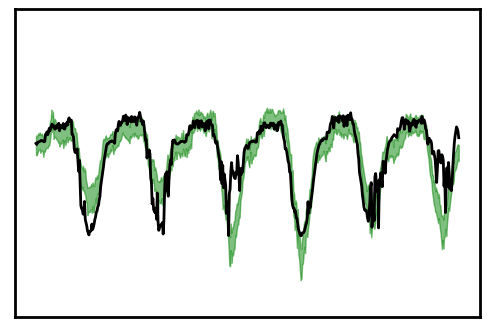

In [50]:
# n = 2
# b = 7
outs = all_samples

n = 2
b = 3
outs = all_samples
plot_x = all_batch_x[:b, :, n].reshape(-1)
plot_y = all_batch_y[:b, :, n].reshape(-1)
plot_outs = outs[:b, :, n, :].detach().cpu().numpy().reshape(-1, 100)
percentiles = np.percentile(plot_outs, [2, 50, 98], axis=1)
percentiles.shape
plt.figure(figsize=(6, 4))
# out = outs[b, :, n, :].detach().cpu().numpy()
i_and_o =  torch.concat([plot_y], dim=0).detach().cpu().numpy() #  T


plt.plot(i_and_o, color='black', linewidth=2, label='Ground Truth')


# percentiles = np.percentile(out, [4, 50, 96], axis=1)

# plt.fill_between(o_index, percentiles[0], percentiles[2], color='green', alpha=0.45, label='Prediction Interval')
# I want to set a good looking color for the prediction interval
# Use a visually appealing gradient color for the prediction interval fill
from matplotlib.colors import LinearSegmentedColormap

# Create a custom colormap that fades from blue to pink to orange
cmap = LinearSegmentedColormap.from_list("pred_interval", ["#7289da", "#e573b3", "#ffa940"])
interval_color = cmap(0.6)  # Use a mid-range color from the colormap

plt.fill_between(
    range(percentiles[0].shape[0]),
    percentiles[0],
    percentiles[2],
    color='green',
    alpha=0.5,
    label='Prediction Interval'
)

# plt.legend()

plt.gca().spines['top'].set_linewidth(2)  # Increase top border thickness
plt.gca().spines['right'].set_linewidth(2)  # Increase right border thickness
plt.gca().spines['left'].set_linewidth(2)   # Increase left border thickness
plt.gca().spines['bottom'].set_linewidth(2) # Increase bottom border thickness
# plt.grid()

plt.ylim([-8, 6])

# plt.show()# I want to remove x axis and y axis ticks
plt.xticks([])
plt.yticks([])
plt.savefig(f'TMDM_ETTm1_case.svg',bbox_inches='tight')

plt.show()

# ALL

## ETTm1

### GroundTruth

In [232]:
self = exp
full_dataset = MultiStepTimeFeatureSet(
    self.dataset,
    scaler=self.scaler,
    time_enc=self.timeenc,
    window=self.windows,
    horizon=self.horizon,
    steps=self.pred_len,
    include_raw=True,
    freq=self.dataset.freq,
    single_variate=False,
    scaler_fit=False,
    time_index=True,
)

all_batch_origin_x = []
all_batch_origin_y = []

all_batch_x = []
all_batch_x_date_enc = []
all_batch_y_date_enc = []
all_batch_y = []

all_x_index = []
all_y_index = []


for i in range(0, len(full_dataset), self.pred_len) :
    batch_x, batch_y, origin_x, origin_y, batch_x_date_enc, batch_y_date_enc, x_index, y_index = full_dataset[i]
    all_batch_origin_x.append(torch.tensor(origin_x))
    all_batch_origin_y.append(torch.tensor(origin_y))
    all_batch_x.append(torch.tensor(batch_x))
    all_batch_y.append(torch.tensor(batch_y))
    all_batch_x_date_enc.append(torch.tensor(batch_x_date_enc))
    all_batch_y_date_enc.append(torch.tensor(batch_y_date_enc))
    
    all_x_index.append(torch.tensor(x_index))
    all_y_index.append(torch.tensor(y_index))
# all_batch_origin_x = torch.stack(all_batch_origin_x, dim=0).to(self.device).float()
# all_batch_origin_y = torch.stack(all_batch_origin_y, dim=0).to(self.device).float()
all_batch_x = torch.stack(all_batch_x, dim=0).to(self.device).float()
all_batch_y = torch.stack(all_batch_y, dim=0).to(self.device).float()
# all_x_date_enc = torch.stack(all_batch_x_date_enc, dim=0).to(self.device).float()[-12:]
# all_y_date_enc = torch.stack(all_batch_y_date_enc, dim=0).to(self.device).float()[-12:]
# all_x_index = torch.stack(all_x_index, dim=0).to(self.device).float()[-12:]
# all_y_index = torch.stack(all_y_index, dim=0).to(self.device).float()[-12:]
# outs = self._val_batch(all_batch_x, all_x_date_enc, all_y_date_enc, all_x_index, all_y_index) # B, T, N

# fig, axes = plt.subplots(all_batch_x.shape[2])


In [233]:
all_batch = torch.concat([all_batch_x, all_batch_y], dim=1)

In [ ]:
# all_batch[:, :, 2].min(0).values.shape

torch.Size([360])

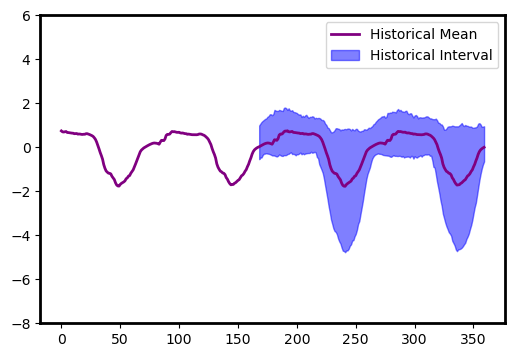

In [234]:
plt.figure(figsize=(6, 4))
# plt.plot(all_batch.detach().cpu().numpy()[-2, :, 2])
q25 = all_batch[:, :, 2].quantile(0.02,0).detach().cpu().numpy()
q75 = all_batch[:, :, 2].quantile(0.98,0).detach().cpu().numpy()
qmean = all_batch[:, :, 2].mean(0).detach().cpu().numpy()
qmin = all_batch[:, :, 2].min(0).values.detach().cpu().numpy()
qmax = all_batch[:, :, 2].max(0).values.detach().cpu().numpy()
plt.plot(qmean, color='purple', linewidth=2, label='Historical Mean')
plt.fill_between(range(168, 360), q25[168:360], q75[168:360], color='blue', alpha=0.5, label='Historical Interval')
plt.ylim([-8, 6])
# plt.yticks([])

plt.gca().spines['top'].set_linewidth(2)  # Increase top border thickness
plt.gca().spines['right'].set_linewidth(2)  # Increase right border thickness
plt.gca().spines['left'].set_linewidth(2)   # Increase left border thickness
plt.gca().spines['bottom'].set_linewidth(2) # Increase bottom border thickness

plt.legend()
plt.savefig(f'{dataset}_groundtruth.svg',bbox_inches='tight')
plt.show()


# all_batch[:, :, 2].std(0)
# all_batch[:, :, 2].median(0)


In [112]:
dataset = 'ETTm1'

### DiffPTS

In [236]:
exp = DiffPTSForecast(
    windows=168,
    pred_len=192,
    # epochs=10,
    # patience=5,
    save_dir='../results',
    data_path='../data',
    dataset_type="ETTm1",
    cond_backbone='patchtst'
)
# exp.run(1)
exp._setup_run(1)
exp._resume_run(1)

Using downloaded and verified file: ../data/ETTm1/ETTm1.csv
train steps: 34201
val steps: 32
test steps: 32


/data/yww/notebook/3110Diff/src/models/DiffPTS.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  assert (torch.tensor(self.betas_tilde) >= 0).all()


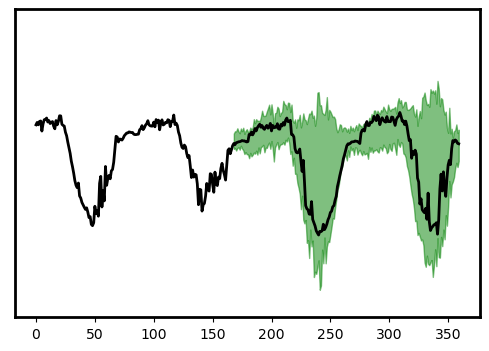

In [237]:
all_samples, all_trues, all_batch_x, all_batch_y, all_x_date_enc, all_y_date_enc = load_samples_trues(exp)
outs = all_samples

n = 2
b = 0
outs = all_samples
plot_x = all_batch_x[b, :, n].reshape(-1)
plot_y = all_batch_y[b, :, n].reshape(-1)
plot_outs = outs[b, :, n, :].detach().cpu().numpy().reshape(-1, 100)
# plot_outs = remove_largest_k(plot_outs, k=20)
percentiles = np.percentile(plot_outs, [4, 50, 96], axis=1)
percentiles.shape
plt.figure(figsize=(6, 4))
# out = outs[b, :, n, :].detach().cpu().numpy()
i_and_o =  torch.concat([plot_x,plot_y], dim=0).detach().cpu().numpy() #  T


plt.plot( i_and_o, color='black', linewidth=2, label='Ground Truth')


from matplotlib.colors import LinearSegmentedColormap

# Create a custom colormap that fades from blue to pink to orange
cmap = LinearSegmentedColormap.from_list("pred_interval", ["#7289da", "#e573b3", "#ffa940"])
interval_color = cmap(0.6)  # Use a mid-range color from the colormap

plt.fill_between(
    range(len(plot_x),len(plot_x)+len(plot_y)),
    percentiles[0],
    percentiles[2],
    color='green',
    alpha=0.5,
    label='Prediction Interval'
)

# plt.legend()

plt.gca().spines['top'].set_linewidth(2)  # Increase top border thickness
plt.gca().spines['right'].set_linewidth(2)  # Increase right border thickness
plt.gca().spines['left'].set_linewidth(2)   # Increase left border thickness
plt.gca().spines['bottom'].set_linewidth(2) # Increase bottom border thickness
# plt.grid()

plt.ylim([-8, 6])
# plt.xtick
# plt.show()# I want to remove x axis and y axis ticks
# plt.xticks([])
plt.yticks([])
plt.savefig(f'DiffPTS_{dataset}_case.svg',bbox_inches='tight')

plt.show()

### NsDiff

In [213]:
exp = NsDiffForecast(
    model_type="NsDiff4",
    windows=168,
    pred_len=192,
    epochs=10,
    patience=5,
    save_dir='../results',
    data_path='../data',
    dataset_type="ETTm1",
    lr=0.001,
    rolling_length=96,
    diffusion_steps=10,
)
# exp.run(1)
exp._setup_run(1)
exp._resume_run(1)

Using downloaded and verified file: ../data/ETTm1/ETTm1.csv
train steps: 34201
val steps: 32
test steps: 32


/data/yww/notebook/3110Diff/src/models/NsDiff.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  assert (torch.tensor(self.betas_tilde) >= 0).all()


In [218]:
self = exp
full_dataset = MultiStepTimeFeatureSet(
    self.dataset,
    scaler=self.scaler,
    time_enc=self.timeenc,
    window=self.windows,
    horizon=self.horizon,
    steps=self.pred_len,
    include_raw=True,
    freq=self.dataset.freq,
    single_variate=False,
    scaler_fit=False,
    time_index=True,
)

all_batch_origin_x = []
all_batch_origin_y = []

all_batch_x = []
all_batch_x_date_enc = []
all_batch_y_date_enc = []
all_batch_y = []

all_x_index = []
all_y_index = []


for i in range(0, len(full_dataset), self.pred_len) :
    batch_x, batch_y, origin_x, origin_y, batch_x_date_enc, batch_y_date_enc, x_index, y_index = full_dataset[i]
    all_batch_origin_x.append(torch.tensor(origin_x))
    all_batch_origin_y.append(torch.tensor(origin_y))
    all_batch_x.append(torch.tensor(batch_x))
    all_batch_y.append(torch.tensor(batch_y))
    all_batch_x_date_enc.append(torch.tensor(batch_x_date_enc))
    all_batch_y_date_enc.append(torch.tensor(batch_y_date_enc))
    
    all_x_index.append(torch.tensor(x_index))
    all_y_index.append(torch.tensor(y_index))
all_batch_origin_x = torch.stack(all_batch_origin_x, dim=0).to(self.device).float()[-12:]
all_batch_origin_y = torch.stack(all_batch_origin_y, dim=0).to(self.device).float()[-12:]
all_batch_x = torch.stack(all_batch_x, dim=0).to(self.device).float()[-12:]
all_batch_y = torch.stack(all_batch_y, dim=0).to(self.device).float()[-12:]
all_x_date_enc = torch.stack(all_batch_x_date_enc, dim=0).to(self.device).float()[-12:]
all_y_date_enc = torch.stack(all_batch_y_date_enc, dim=0).to(self.device).float()[-12:]
all_x_index = torch.stack(all_x_index, dim=0).to(self.device).float()[-12:]
all_y_index = torch.stack(all_y_index, dim=0).to(self.device).float()[-12:]
# outs = self._val_batch(all_batch_x, all_x_date_enc, all_y_date_enc, all_x_index, all_y_index) # B, T, N

all_samples, all_trues = self._process_val_batch(
    all_batch_x, all_batch_y, all_x_date_enc, all_y_date_enc
)

# fig, axes = plt.subplots(all_batch_x.shape[2])


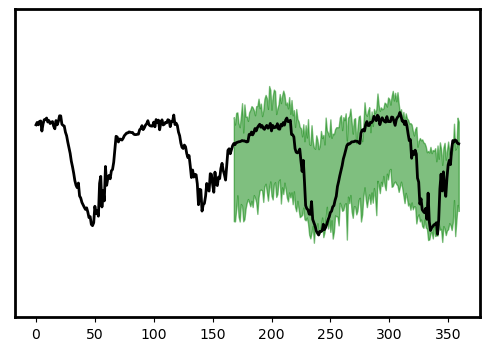

In [221]:
outs = all_samples

n = 2
b = 0
outs = all_samples
plot_x = all_batch_x[b, :, n].reshape(-1)
plot_y = all_batch_y[b, :, n].reshape(-1)
plot_outs = outs[b, :, n, :].detach().cpu().numpy().reshape(-1, 100)
# plot_outs = remove_largest_k(plot_outs, k=20)
percentiles = np.percentile(plot_outs, [4, 50, 96], axis=1)
percentiles.shape
plt.figure(figsize=(6, 4))
# out = outs[b, :, n, :].detach().cpu().numpy()
i_and_o =  torch.concat([plot_x,plot_y], dim=0).detach().cpu().numpy() #  T


plt.plot( i_and_o, color='black', linewidth=2, label='Ground Truth')


# percentiles = np.percentile(out, [4, 50, 96], axis=1)

# plt.fill_between(o_index, percentiles[0], percentiles[2], color='green', alpha=0.45, label='Prediction Interval')
# I want to set a good looking color for the prediction interval
# Use a visually appealing gradient color for the prediction interval fill
from matplotlib.colors import LinearSegmentedColormap

# Create a custom colormap that fades from blue to pink to orange
cmap = LinearSegmentedColormap.from_list("pred_interval", ["#7289da", "#e573b3", "#ffa940"])
interval_color = cmap(0.6)  # Use a mid-range color from the colormap

plt.fill_between(
    range(len(plot_x),len(plot_x)+len(plot_y)),
    percentiles[0],
    percentiles[2],
    color='green',
    alpha=0.5,
    label='Prediction Interval'
)

# plt.legend()

plt.gca().spines['top'].set_linewidth(2)  # Increase top border thickness
plt.gca().spines['right'].set_linewidth(2)  # Increase right border thickness
plt.gca().spines['left'].set_linewidth(2)   # Increase left border thickness
plt.gca().spines['bottom'].set_linewidth(2) # Increase bottom border thickness
# plt.grid()

plt.ylim([-8, 6])
# plt.xtick
# plt.show()# I want to remove x axis and y axis ticks
# plt.xticks([])

plt.yticks([])
plt.savefig(f'NsDiff_{dataset}_case.svg',bbox_inches='tight')

plt.show()

### RDIT

In [209]:
import matplotlib.pyplot as plt
import numpy as np

import os
import sys
import torch
import time
import seaborn as sns
sys.path.insert(0,os.path.abspath('/data/yww/notebook/pytorchtimseries'))
sys.path.insert(0,os.path.abspath('/data/yww/notebook/3110Diff'))

from torch_timeseries.dataloader.wrapper import MultiStepTimeFeatureSet, MultivariateFast
from torch.utils.data.dataloader import DataLoader

from src.experiments.RDIT import RDITForecast

exp = RDITForecast(
    windows=168,
    pred_len=192,
    save_dir='../results',
    data_path='../data',
    dataset_type=dataset,
    sigma_mode='res',
)
exp._setup_run(1)
exp._resume_run(1)

Using downloaded and verified file: ../data/ETTm1/ETTm1.csv
train steps: 34201
val steps: 32
test steps: 32


/data/yww/notebook/3110Diff/src/models/DiffPTS.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  assert (torch.tensor(self.betas_tilde) >= 0).all()


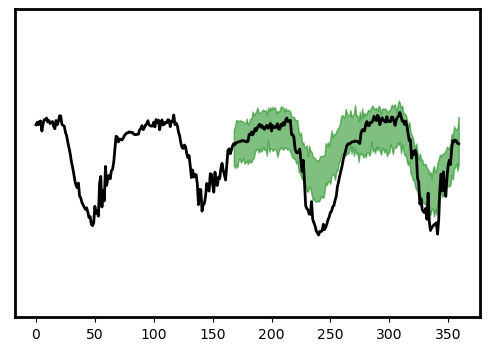

In [211]:
all_samples, all_trues, all_batch_x, all_batch_y, all_x_date_enc, all_y_date_enc = load_samples_trues(exp)
outs = all_samples

n = 2
b = 0
outs = all_samples
plot_x = all_batch_x[b, :, n].reshape(-1)
plot_y = all_batch_y[b, :, n].reshape(-1)
plot_outs = outs[b, :, n, :].detach().cpu().numpy().reshape(-1, 100)
# plot_outs = remove_largest_k(plot_outs, k=20)
percentiles = np.percentile(plot_outs, [4, 50, 96], axis=1)
percentiles.shape
plt.figure(figsize=(6, 4))
# out = outs[b, :, n, :].detach().cpu().numpy()
i_and_o =  torch.concat([plot_x,plot_y], dim=0).detach().cpu().numpy() #  T


plt.plot( i_and_o, color='black', linewidth=2, label='Ground Truth')


from matplotlib.colors import LinearSegmentedColormap

# Create a custom colormap that fades from blue to pink to orange
cmap = LinearSegmentedColormap.from_list("pred_interval", ["#7289da", "#e573b3", "#ffa940"])
interval_color = cmap(0.6)  # Use a mid-range color from the colormap

plt.fill_between(
    range(len(plot_x),len(plot_x)+len(plot_y)),
    percentiles[0],
    percentiles[2],
    color='green',
    alpha=0.5,
    label='Prediction Interval'
)

# plt.legend()

plt.gca().spines['top'].set_linewidth(2)  # Increase top border thickness
plt.gca().spines['right'].set_linewidth(2)  # Increase right border thickness
plt.gca().spines['left'].set_linewidth(2)   # Increase left border thickness
plt.gca().spines['bottom'].set_linewidth(2) # Increase bottom border thickness
# plt.grid()

plt.ylim([-8, 6])
# plt.xtick
# plt.show()# I want to remove x axis and y axis ticks
# plt.xticks([])
plt.yticks([])
plt.savefig(f'RDIT_{dataset}_case.svg',bbox_inches='tight')

plt.show()

### D3U

In [228]:
import matplotlib.pyplot as plt
import numpy as np

import os
import sys
import torch
import time
import seaborn as sns
sys.path.insert(0,os.path.abspath('/data/yww/notebook/pytorchtimseries'))
sys.path.insert(0,os.path.abspath('/data/yww/notebook/3110Diff'))

from torch_timeseries.dataloader.wrapper import MultiStepTimeFeatureSet, MultivariateFast
from torch.utils.data.dataloader import DataLoader

from src.experiments.D3U import D3UForecast

exp = D3UForecast(
    windows=168,
    pred_len=192,
    save_dir='../results',
    data_path='../data',
    dataset_type="ETTm1",
)
# exp.run(1)
exp._setup_run(1)
exp._resume_run(1)


all_samples, all_trues, all_batch_x, all_batch_y, all_x_date_enc, all_y_date_enc = load_samples_trues(exp)
# dec_inp_pred = torch.zeros(
#     [all_batch_x.size(0), exp.pred_len, exp.dataset.num_features]
# ).to(exp.device)
# dec_inp_label = all_batch_x[:, -exp.label_len :, :].to(exp.device)
# dec_inp = torch.cat([dec_inp_label, dec_inp_pred], dim=1)
# label_date = torch.concat([all_x_date_enc[:, -self.label_len:, :], all_y_date_enc], dim=1)


# fx, _ = exp.cond_pred_model(all_batch_x, all_x_date_enc, dec_inp, label_date) #+ EPS # (B, O, N)
# gx = exp.cond_pred_model_g(all_batch_x) #+ EPS # (B, O, N)


Using downloaded and verified file: ../data/ETTm1/ETTm1.csv
train steps: 34201
val steps: 32
test steps: 32


/data/yww/notebook/3110Diff/src/models/D3U.py:44: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  assert (torch.tensor(self.betas_tilde) >= 0).all()


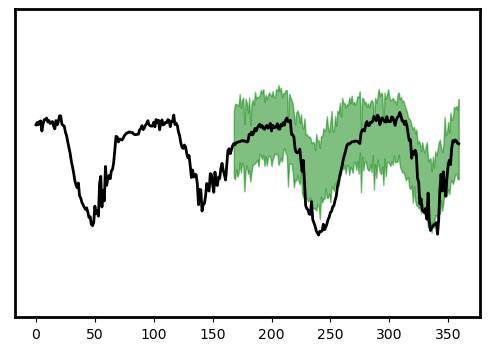

In [231]:
outs = all_samples

n = 2
b = 0
outs = all_samples
plot_x = all_batch_x[b, :, n].reshape(-1)
plot_y = all_batch_y[b, :, n].reshape(-1)
plot_outs = outs[b, :, n, :].detach().cpu().numpy().reshape(-1, 100)
# plot_outs = remove_largest_k(plot_outs, k=20)
percentiles = np.percentile(plot_outs, [4, 50, 96], axis=1)
percentiles.shape
plt.figure(figsize=(6, 4))
# out = outs[b, :, n, :].detach().cpu().numpy()
i_and_o =  torch.concat([plot_x,plot_y], dim=0).detach().cpu().numpy() #  T


plt.plot( i_and_o, color='black', linewidth=2, label='Ground Truth')


from matplotlib.colors import LinearSegmentedColormap

# Create a custom colormap that fades from blue to pink to orange
cmap = LinearSegmentedColormap.from_list("pred_interval", ["#7289da", "#e573b3", "#ffa940"])
interval_color = cmap(0.6)  # Use a mid-range color from the colormap

plt.fill_between(
    range(len(plot_x),len(plot_x)+len(plot_y)),
    percentiles[0],
    percentiles[2],
    color='green',
    alpha=0.5,
    label='Prediction Interval'
)

# plt.legend()

plt.gca().spines['top'].set_linewidth(2)  # Increase top border thickness
plt.gca().spines['right'].set_linewidth(2)  # Increase right border thickness
plt.gca().spines['left'].set_linewidth(2)   # Increase left border thickness
plt.gca().spines['bottom'].set_linewidth(2) # Increase bottom border thickness
# plt.grid()
plt.yticks([])

plt.ylim([-8, 6])
plt.savefig(f'D3U_{dataset}_case.svg',bbox_inches='tight')

# plt.show()# I want to remove x axis and y axis ticks
# plt.xticks([])

plt.show()

### TMDM

## ETTm2

In [238]:
dataset = 'ETTm2'

In [224]:
exp = TMDMForecast(
    windows=168,
    pred_len=192,
    # epochs=10,
    # patience=5,
    save_dir='../results',
    data_path='../data',
    dataset_type=dataset,
    # cond_backbone='patchtst'
)
exp._setup_run(1)
exp._resume_run(1)


Using downloaded and verified file: ../data/ETTm1/ETTm1.csv
train steps: 34201
val steps: 32
test steps: 32


In [226]:
self = exp
full_dataset = MultiStepTimeFeatureSet(
    self.dataset,
    scaler=self.scaler,
    time_enc=self.timeenc,
    window=self.windows,
    horizon=self.horizon,
    steps=self.pred_len,
    include_raw=True,
    freq=self.dataset.freq,
    single_variate=False,
    scaler_fit=False,
    time_index=True,
)

all_batch_origin_x = []
all_batch_origin_y = []

all_batch_x = []
all_batch_x_date_enc = []
all_batch_y_date_enc = []
all_batch_y = []

all_x_index = []
all_y_index = []


for i in range(0, len(full_dataset), self.pred_len) :
    batch_x, batch_y, origin_x, origin_y, batch_x_date_enc, batch_y_date_enc, x_index, y_index = full_dataset[i]
    all_batch_origin_x.append(torch.tensor(origin_x))
    all_batch_origin_y.append(torch.tensor(origin_y))
    all_batch_x.append(torch.tensor(batch_x))
    all_batch_y.append(torch.tensor(batch_y))
    all_batch_x_date_enc.append(torch.tensor(batch_x_date_enc))
    all_batch_y_date_enc.append(torch.tensor(batch_y_date_enc))
    
    all_x_index.append(torch.tensor(x_index))
    all_y_index.append(torch.tensor(y_index))
all_batch_origin_x = torch.stack(all_batch_origin_x, dim=0).to(self.device).float()[-12:]
all_batch_origin_y = torch.stack(all_batch_origin_y, dim=0).to(self.device).float()[-12:]
all_batch_x = torch.stack(all_batch_x, dim=0).to(self.device).float()[-12:]
all_batch_y = torch.stack(all_batch_y, dim=0).to(self.device).float()[-12:]
all_x_date_enc = torch.stack(all_batch_x_date_enc, dim=0).to(self.device).float()[-12:]
all_y_date_enc = torch.stack(all_batch_y_date_enc, dim=0).to(self.device).float()[-12:]
all_x_index = torch.stack(all_x_index, dim=0).to(self.device).float()[-12:]
all_y_index = torch.stack(all_y_index, dim=0).to(self.device).float()[-12:]
# outs = self._val_batch(all_batch_x, all_x_date_enc, all_y_date_enc, all_x_index, all_y_index) # B, T, N

all_samples, all_trues = self._process_val_batch(
    all_batch_x, all_batch_y, all_x_date_enc, all_y_date_enc
)

# fig, axes = plt.subplots(all_batch_x.shape[2])


t: 0.18770742416381836
t: 0.1844930648803711
t: 0.18634986877441406
t: 0.1864175796508789
t: 0.18618392944335938
t: 0.1860055923461914
t: 0.18612360954284668
t: 0.18718481063842773
t: 0.18712258338928223
t: 0.185746431350708
t: 0.18959307670593262
t: 0.19011187553405762
t: 0.18740105628967285
t: 0.19000458717346191
t: 0.1897258758544922
t: 0.18629193305969238
t: 0.18871545791625977
t: 0.18824076652526855
t: 0.18878746032714844
t: 0.18864870071411133
t: 0.18818140029907227
t: 0.18665194511413574
t: 0.18709397315979004
t: 0.18657708168029785
t: 0.1881873607635498
t: 0.18699145317077637
t: 0.19141578674316406
t: 0.19104504585266113
t: 0.19579076766967773
t: 0.19135642051696777
t: 0.19063067436218262
t: 0.18773198127746582
t: 0.18930816650390625
t: 0.18683075904846191
t: 0.1872549057006836
t: 0.18715262413024902
t: 0.18809986114501953
t: 0.18672513961791992
t: 0.18804597854614258
t: 0.18773412704467773
t: 0.18715763092041016
t: 0.1866457462310791
t: 0.18744492530822754
t: 0.187974452972412

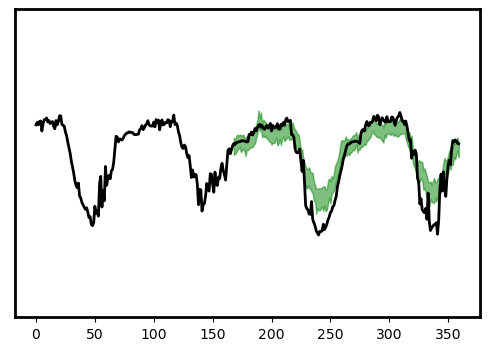

In [227]:
outs = all_samples

n = 2
b = 0
outs = all_samples
plot_x = all_batch_x[b, :, n].reshape(-1)
plot_y = all_batch_y[b, :, n].reshape(-1)
plot_outs = outs[b, :, n, :].detach().cpu().numpy().reshape(-1, 100)
# plot_outs = remove_largest_k(plot_outs, k=20)
percentiles = np.percentile(plot_outs, [4, 50, 96], axis=1)
percentiles.shape
plt.figure(figsize=(6, 4))
# out = outs[b, :, n, :].detach().cpu().numpy()
i_and_o =  torch.concat([plot_x,plot_y], dim=0).detach().cpu().numpy() #  T


plt.plot( i_and_o, color='black', linewidth=2, label='Ground Truth')


from matplotlib.colors import LinearSegmentedColormap

# Create a custom colormap that fades from blue to pink to orange
cmap = LinearSegmentedColormap.from_list("pred_interval", ["#7289da", "#e573b3", "#ffa940"])
interval_color = cmap(0.6)  # Use a mid-range color from the colormap

plt.fill_between(
    range(len(plot_x),len(plot_x)+len(plot_y)),
    percentiles[0],
    percentiles[2],
    color='green',
    alpha=0.5,
    label='Prediction Interval'
)

# plt.legend()

plt.gca().spines['top'].set_linewidth(2)  # Increase top border thickness
plt.gca().spines['right'].set_linewidth(2)  # Increase right border thickness
plt.gca().spines['left'].set_linewidth(2)   # Increase left border thickness
plt.gca().spines['bottom'].set_linewidth(2) # Increase bottom border thickness
# plt.grid()
plt.yticks([])

plt.ylim([-8, 6])
plt.savefig(f'TMDM_{dataset}_case.svg',bbox_inches='tight')

# plt.show()# I want to remove x axis and y axis ticks
# plt.xticks([])

plt.show()

## ETTh1

In [100]:
dataset = 'ETTh1'

In [101]:
exp = DiffPTSForecast(
    windows=168,
    pred_len=192,
    # epochs=10,
    # patience=5,
    save_dir='../results',
    data_path='../data',
    dataset_type=dataset,
    # cond_backbone='patchtst'
)
exp._setup_run(1)
exp._resume_run(1)

all_samples, all_trues, all_batch_x, all_batch_y, all_x_date_enc, all_y_date_enc = load_samples_trues(exp)
dec_inp_pred = torch.zeros(
    [all_batch_x.size(0), exp.pred_len, exp.dataset.num_features]
).to(exp.device)
dec_inp_label = all_batch_x[:, -exp.label_len :, :].to(exp.device)
dec_inp = torch.cat([dec_inp_label, dec_inp_pred], dim=1)
label_date = torch.concat([all_x_date_enc[:, -self.label_len:, :], all_y_date_enc], dim=1)


fx, _ = exp.cond_pred_model(all_batch_x, all_x_date_enc, dec_inp, label_date) #+ EPS # (B, O, N)
gx = exp.cond_pred_model_g(all_batch_x) #+ EPS # (B, O, N)


Using downloaded and verified file: ../data/ETTh1/ETTh1.csv
train steps: 8281
val steps: 8
test steps: 8


/data/yww/notebook/3110Diff/src/models/DiffPTS.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  assert (torch.tensor(self.betas_tilde) >= 0).all()


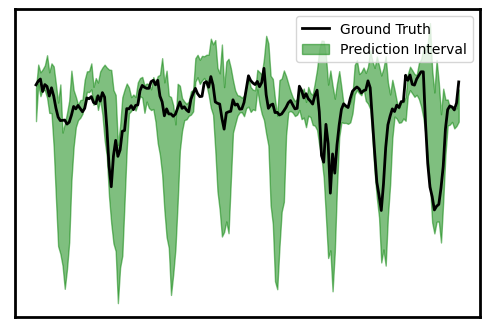

In [ ]:
outs = all_samples

n = 0
b = 1
outs = all_samples
plot_x = all_batch_x[:b, :, n].reshape(-1)
plot_y = all_batch_y[:b, :, n].reshape(-1)
plot_outs = outs[:b, :, n, :].detach().cpu().numpy().reshape(-1, 100)
# plot_outs = remove_largest_k(plot_outs, k=20)
percentiles = np.percentile(plot_outs, [2, 50, 98], axis=1)
percentiles.shape
plt.figure(figsize=(6, 4))
# out = outs[b, :, n, :].detach().cpu().numpy()
i_and_o =  torch.concat([plot_x, plot_y], dim=0).detach().cpu().numpy() #  T


plt.plot(i_and_o, color='black', linewidth=2, label='Ground Truth')


# percentiles = np.percentile(out, [4, 50, 96], axis=1)

# plt.fill_between(o_index, percentiles[0], percentiles[2], color='green', alpha=0.45, label='Prediction Interval')
# I want to set a good looking color for the prediction interval
# Use a visually appealing gradient color for the prediction interval fill
from matplotlib.colors import LinearSegmentedColormap

# Create a custom colormap that fades from blue to pink to orange
cmap = LinearSegmentedColormap.from_list("pred_interval", ["#7289da", "#e573b3", "#ffa940"])
interval_color = cmap(0.6)  # Use a mid-range color from the colormap

plt.fill_between(
    range(percentiles[0].shape[0]),
    percentiles[0],
    percentiles[2],
    color='green',
    alpha=0.5,
    label='Prediction Interval'
)

plt.legend()

plt.gca().spines['top'].set_linewidth(2)  # Increase top border thickness
plt.gca().spines['right'].set_linewidth(2)  # Increase right border thickness
plt.gca().spines['left'].set_linewidth(2)   # Increase left border thickness
plt.gca().spines['bottom'].set_linewidth(2) # Increase bottom border thickness
# plt.grid()

# plt.ylim([-8, 6])

# plt.show()# I want to remove x axis and y axis ticks
plt.xticks([])
plt.yticks([])
plt.savefig(f'DiffPTS_{dataset}_case.svg',bbox_inches='tight')

plt.show()

## ETTm2

In [235]:
dataset = 'ETTm2'

In [ ]:
exp = NsDiffForecast(
    model_type="NsDiff4",
    windows=168,
    pred_len=192,
    epochs=10,
    patience=5,
    save_dir='../results',
    data_path='../data',
    dataset_type="ETTm1",
    lr=0.001,
    rolling_length=96,
    diffusion_steps=10,
)
# exp.run(1)
exp._setup_run(1)
exp._resume_run(1)